# Water Quality Prediction — Geology-Aware Model (Ridge + XGBoost Ensemble)

## Key design choices

### Why NO geographic features
Training sites span Western Cape / Karoo / Limpopo / KZN; validation is Eastern Cape — a different geological region.
Ridge with lat/lon learns "lat −33 = low TA" which misapplies to Eastern Cape. External R² with geography: **−0.452**.

### Geology feature strategy
| Level | Features | Key signal |
|---|---|---|
| Soil chemistry | `soil_ph`, `soil_cec`, `soil_oc` | ion exchange, alkalinity buffering |
| Legacy flags | `is_carbonate`, `is_evaporite` | direct carbonate bedrock |
| Supergroup | `is_karoo_supergroup`, `is_cape_supergroup` | Karoo mudstone (TA≈121) vs Cape quartzite (TA≈54) |
| Rock age | `macrostrat_age_ma` | younger = softer = more ions released |
| Sub-Karoo | `is_ecca_group`, `is_beaufort_group`, `is_dwyka_group`, `is_karoo_dolerite` | Ecca shale (TA≈138) vs Beaufort mudstone (TA≈101) |

### Why GLIM class features were dropped
`glim_ss` collapses Cape quartzite (TA≈54) and Karoo mudstone (TA≈121) into one class.
All Eastern Cape validation sites = `glim_ss`, so the model underpredicted TA. External score with GLIM: **−0.04**.
Replaced by formation-level flags from `macrostrat_name` which correctly distinguishes the two.

### Spatial CV progression
| Model | CV avg | TA | EC | DRP |
|---|---|---|---|---|
| No-geology baseline | 0.182 | 0.232 | 0.238 | 0.076 |
| + GLIM class dummies | 0.244 | 0.335 | 0.276 | 0.121 |
| + Karoo/Cape + age_ma | 0.308 | 0.356 | 0.351 | 0.217 |
| + Sub-Karoo flags (current) | **0.307** | **0.352** | **0.364** | **0.203** |

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
print("Dependencies loaded.")

Dependencies loaded.


In [2]:
# ── Load merged data ───────────────────────────────────────────────────────────
# New pre-merged CSVs contain: TerraClimate, Landsat, soil, geology, land use
train           = pd.read_csv('../Data/training_merged.csv')
val             = pd.read_csv('../Data/validation_merged.csv')
submission_tmpl = pd.read_csv('../Data/submission_template.csv')

print(f"Training rows     : {len(train):,}")
print(f"Unique train sites : {train.groupby(['Latitude','Longitude']).ngroups}")
print(f"Validation rows   : {len(val)}")
print(f"Unique val sites  : {val.groupby(['Latitude','Longitude']).ngroups}")
print(f"\nAll columns ({len(train.columns)}):")
print(list(train.columns))

Training rows     : 8,985
Unique train sites : 162
Validation rows   : 200
Unique val sites  : 24

All columns (86):
['Latitude', 'Longitude', 'Sample Date', 'swir22', 'NDMI', 'MNDWI', 'thermal', 'NDWI', 'NDVI', 'BSI', 'red_turbidity', 'month', 'landsat_missing', 'pet', 'ppt', 'tmax', 'soil', 'q', 'aet', 'def', 'aridity', 'seasonal_wetness', 'water_stress', 'dist_to_industrial_km', 'industrial_count_10km', 'industrial_count_25km', 'industrial_count_50km', 'dist_to_active_mine_km', 'active_mine_count_25km', 'active_mine_count_50km', 'dist_to_tsf_km', 'tsf_count_25km', 'tsf_count_50km', 'pct_agricultural', 'pct_industrial', 'pct_urban', 'pct_natural', 'dist_to_hydro_plant_km', 'dist_to_thermal_plant_km', 'waterway_count_5km', 'waterway_length_5km_m', 'evi', 'lswi', 'blue_red_ratio', 'nir_red_ratio', 'runoff_coeff', 'baseflow_index', 'thermal_conc', 'bio_P_uptake', 'seasonal_drp_pulse', 'soil_ph', 'soil_cec', 'soil_oc', 'is_carbonate', 'is_evaporite', 'carbonate_dissolution', 'Total Alkal

In [3]:
# ── Feature engineering ────────────────────────────────────────────────────────

def _formation_flags(name: str) -> dict:
    """
    Parse macrostrat_name into binary geology flags.

    Sub-Karoo distinctions (training TA mean):
      Ecca Group (shale/coal-bearing)  → TA≈138, EC≈552  — highest
      Dwyka Group (glacial diamictite) → TA≈121, EC≈524
      Karoo Dolerite (basic intrusion) → TA≈115, EC≈297
      Beaufort Group (mudstone/silt)   → TA≈101, EC≈257  — lowest of Karoo

    Eastern Cape validation is ~54% Beaufort + ~24% Ecca + ~16% Cape + ~9% other.
    """
    n = str(name).lower()

    # Supergroup-level
    is_karoo = int(any(k in n for k in [
        'karoo', 'beaufort', 'ecca', 'dwyka', 'molteno', 'elliot', 'clarens',
        'vryheid', 'volksrust', 'tarkastad', 'fort brown', 'waterford',
        'prince albert', 'emakwezini', 'pietermaritzburg', 'dolerite',
    ]))
    is_cape = int(any(k in n for k in [
        'cape supergroup', 'witteberg', 'bokkeveld', 'table mountain',
        'nardouw', 'ceres subgroup', 'natal group',
    ]))

    # Sub-Karoo groups
    is_beaufort = int(any(k in n for k in [
        'beaufort', 'tarkastad', 'adelaide', 'molteno', 'elliot',
        'clarens', 'emakwezini',
    ]))
    is_ecca = int(any(k in n for k in [
        'ecca', 'volksrust', 'vryheid', 'fort brown', 'waterford',
        'prince albert', 'pietermaritzburg',
    ]))
    is_dwyka    = int('dwyka' in n)
    is_dolerite = int('dolerite' in n)

    return {
        'is_karoo_supergroup': is_karoo,
        'is_cape_supergroup':  is_cape,
        'is_beaufort_group':   is_beaufort,
        'is_ecca_group':       is_ecca,
        'is_dwyka_group':      is_dwyka,
        'is_karoo_dolerite':   is_dolerite,
    }


def engineer_features(df):
    d = df.copy()
    d['Sample Date'] = pd.to_datetime(d['Sample Date'], dayfirst=True)
    d['year']          = d['Sample Date'].dt.year
    d['month_sin']     = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']     = np.cos(2 * np.pi * d['month'] / 12)
    d['is_wet_season'] = d['month'].isin([10, 11, 12, 1, 2, 3]).astype(int)
    d['site_key']      = d['Latitude'].astype(str) + '_' + d['Longitude'].astype(str)

    # Formation flags
    flags_df = d['macrostrat_name'].apply(lambda x: pd.Series(_formation_flags(x)))
    for col in flags_df.columns:
        d[col] = flags_df[col].values

    # Climate ratios
    d['aet_pet']          = d['aet'] / (d['pet'] + 1)
    d['moisture_surplus'] = d['ppt'] - d['aet']

    # Physical interactions
    d['ppt_x_NDMI']    = d['ppt']  * d['NDMI']
    d['q_x_turbidity'] = d['q']    * d['red_turbidity']
    d['ppt_x_soil']    = d['ppt']  * d['soil']
    d['def_x_MNDWI']   = d['def']  * d['MNDWI']
    d['soil_x_NDWI']   = d['soil'] * d['NDWI']
    d['aet_x_NDMI']    = d['aet']  * d['NDMI']

    # Legacy geology × climate
    d['carbonate_x_aridity']  = d['is_carbonate']    * d['aridity']
    d['soil_ph_x_ppt']        = d['soil_ph']          * d['ppt']
    d['soil_cec_x_soil']      = d['soil_cec']         * d['soil']
    d['carbonate_x_baseflow'] = d['is_carbonate']     * d['baseflow_index']
    d['agri_x_ppt']           = d['pct_agricultural'] * d['ppt']

    # Supergroup × climate
    d['karoo_x_ppt']      = d['is_karoo_supergroup'] * d['ppt']
    d['karoo_x_aridity']  = d['is_karoo_supergroup'] * d['aridity']
    d['karoo_x_baseflow'] = d['is_karoo_supergroup'] * d['baseflow_index']
    d['cape_x_ppt']       = d['is_cape_supergroup']  * d['ppt']
    d['cape_x_aridity']   = d['is_cape_supergroup']  * d['aridity']
    d['age_x_aridity']    = d['macrostrat_age_ma']   * d['aridity']
    d['age_x_ppt']        = d['macrostrat_age_ma']   * d['ppt']

    # Sub-Karoo × climate (key new signals)
    d['ecca_x_ppt']       = d['is_ecca_group']     * d['ppt']
    d['ecca_x_aridity']   = d['is_ecca_group']     * d['aridity']
    d['ecca_x_baseflow']  = d['is_ecca_group']     * d['baseflow_index']
    d['beaufort_x_ppt']   = d['is_beaufort_group'] * d['ppt']
    d['beaufort_x_aridity']= d['is_beaufort_group']* d['aridity']

    return d

print("Feature engineering defined.")

Feature engineering defined.


In [4]:
# ── Build train and validation sets ───────────────────────────────────────────
train = engineer_features(pd.read_csv('../Data/training_merged.csv'))
val   = engineer_features(pd.read_csv('../Data/validation_merged.csv'))

FEATURE_COLS = [
    # TerraClimate
    'pet', 'ppt', 'tmax', 'soil', 'q', 'aet', 'def',
    # Climate ratios
    'aridity', 'seasonal_wetness', 'water_stress', 'runoff_coeff', 'baseflow_index',
    'aet_pet', 'moisture_surplus',
    # Temporal
    'month_sin', 'month_cos', 'is_wet_season', 'year',
    # Landsat
    'NDMI', 'MNDWI', 'NDWI', 'NDVI', 'BSI', 'red_turbidity',
    'evi', 'lswi', 'blue_red_ratio', 'nir_red_ratio', 'thermal', 'swir22',
    # Biological / DRP-specific
    'bio_P_uptake', 'seasonal_drp_pulse', 'thermal_conc',
    # Physical interactions
    'ppt_x_NDMI', 'q_x_turbidity', 'ppt_x_soil', 'def_x_MNDWI', 'soil_x_NDWI', 'aet_x_NDMI',
    # Soil chemistry
    'soil_ph', 'soil_cec', 'soil_oc',
    # Legacy geology flags
    'is_carbonate', 'is_evaporite', 'carbonate_dissolution',
    # Land use
    'pct_agricultural', 'pct_urban', 'pct_natural',
    # Legacy geology × climate
    'carbonate_x_aridity', 'soil_ph_x_ppt', 'soil_cec_x_soil',
    'carbonate_x_baseflow', 'agri_x_ppt',
    # ── Supergroup-level geology ──────────────────────────────────────────────
    'is_karoo_supergroup', 'is_cape_supergroup',
    'macrostrat_age_ma',
    'karoo_x_ppt', 'karoo_x_aridity', 'karoo_x_baseflow',
    'cape_x_ppt',  'cape_x_aridity',
    'age_x_aridity', 'age_x_ppt',
    # ── Sub-Karoo formation flags (Priority 1 improvement) ───────────────────
    # Ecca (shale/coal): TA≈138, EC≈552 — highest in Karoo
    # Dwyka (diamictite): TA≈121, EC≈524
    # Dolerite (basic intrusion): TA≈115, EC≈297
    # Beaufort (mudstone/silt): TA≈101, EC≈257 — lowest in Karoo
    'is_beaufort_group',
    'is_ecca_group',
    'is_dwyka_group',
    'is_karoo_dolerite',
    # Sub-Karoo × climate interactions
    'ecca_x_ppt', 'ecca_x_aridity', 'ecca_x_baseflow',
    'beaufort_x_ppt', 'beaufort_x_aridity',
]

TARGET_COLS = {
    'TA':  'Total Alkalinity',
    'EC':  'Electrical Conductance',
    'DRP': 'Dissolved Reactive Phosphorus',
}

location_groups = pd.factorize(train['site_key'])[0]

print(f"Training rows    : {len(train):,}")
print(f"Feature columns  : {len(FEATURE_COLS)}")
print(f"Unique sites     : {len(set(location_groups))}")
print(f"Missing values   : {train[FEATURE_COLS].isna().sum().sum()}")
print()
print("Sub-Karoo coverage — train vs val:")
for col in ['is_beaufort_group', 'is_ecca_group', 'is_dwyka_group', 'is_karoo_dolerite',
            'is_cape_supergroup', 'macrostrat_age_ma']:
    tm, vm = train[col].mean(), val[col].mean()
    print(f"  {col:22s}: train={tm:.3f}  val={vm:.3f}")
print()
print("TA/EC by sub-Karoo group (training):")
for grp, col in [('Ecca','is_ecca_group'), ('Dwyka','is_dwyka_group'),
                  ('Dolerite','is_karoo_dolerite'), ('Beaufort','is_beaufort_group'),
                  ('Cape','is_cape_supergroup')]:
    m = train[col] == 1
    if m.sum() == 0: continue
    print(f"  {grp:10s} n={m.sum():4d}  "
          f"TA={train.loc[m,'Total Alkalinity'].mean():.1f}  "
          f"EC={train.loc[m,'Electrical Conductance'].mean():.1f}")

Training rows    : 8,985
Feature columns  : 72
Unique sites     : 163
Missing values   : 480

Sub-Karoo coverage — train vs val:
  is_beaufort_group     : train=0.159  val=0.610
  is_ecca_group         : train=0.191  val=0.010
  is_dwyka_group        : train=0.075  val=0.000
  is_karoo_dolerite     : train=0.039  val=0.160
  is_cape_supergroup    : train=0.089  val=0.125
  macrostrat_age_ma     : train=1096.018  val=257.309

TA/EC by sub-Karoo group (training):
  Ecca       n=1717  TA=138.2  EC=552.2
  Dwyka      n= 675  TA=120.8  EC=523.8
  Dolerite   n= 351  TA=115.2  EC=297.4
  Beaufort   n=1430  TA=100.9  EC=257.5
  Cape       n= 798  TA=53.7  EC=423.1


In [5]:
# ── GLIM Diagnostics: why glim_class hurts external performance ───────────────
# The core question: does "glim_ss" mean the same thing across all SA regions?

train_raw = pd.read_csv('../Data/training_merged.csv')

print("=== TA by GLIM class (training sites only) ===")
glim_ta = (train_raw.groupby('glim_class')['Total Alkalinity']
           .agg(['mean', 'median', 'std', 'count'])
           .sort_values('mean', ascending=False))
print(glim_ta.to_string())

print("\n=== Within glim_ss class: TA by formation group ===")
ss_mask = train_raw['glim_class'] == 'ss'
ss_df = train_raw[ss_mask].copy()

# Tag formation type from macrostrat_name
def tag_formation(name):
    n = str(name).lower()
    if 'karoo' in n or 'beaufort' in n or 'ecca' in n or 'dwyka' in n or 'molteno' in n \
       or 'elliot' in n or 'clarens' in n or 'vryheid' in n or 'volksrust' in n \
       or 'tarkastad' in n or 'fort brown' in n or 'waterford' in n or 'prince albert' in n:
        return 'Karoo_Supergroup'
    elif 'cape' in n or 'witteberg' in n or 'bokkeveld' in n or 'table mountain' in n \
         or 'nardouw' in n or 'ceres' in n or 'natal' in n:
        return 'Cape_Supergroup'
    elif 'waterberg' in n or 'transvaal' in n or 'witwatersrand' in n:
        return 'Transvaal_Supergroup'
    else:
        return 'Other'

ss_df['formation_group'] = ss_df['macrostrat_name'].apply(tag_formation)
print(ss_df.groupby('formation_group')['Total Alkalinity']
      .agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).to_string())

print("\n=== Validation GLIM classes ===")
val_raw = pd.read_csv('../Data/validation_merged.csv')
print(val_raw['glim_class'].value_counts().to_string())

print("\n=== Validation macrostrat formations (unique) ===")
val_formations = val_raw['macrostrat_name'].apply(tag_formation)
print(val_formations.value_counts().to_string())
print("\nFormation names in validation:")
for name in val_raw['macrostrat_name'].unique():
    print(f"  {name} → {tag_formation(name)}")

print("\n=== Key insight ===")
karoo_ta = ss_df[ss_df['formation_group']=='Karoo_Supergroup']['Total Alkalinity'].mean()
cape_ta  = ss_df[ss_df['formation_group']=='Cape_Supergroup']['Total Alkalinity'].mean()
print(f"Karoo Supergroup ss sites  → mean TA = {karoo_ta:.1f}")
print(f"Cape Supergroup ss sites   → mean TA = {cape_ta:.1f}")
print(f"All ss sites (training)    → mean TA = {ss_df['Total Alkalinity'].mean():.1f}")
print(f"All training sites         → mean TA = {train_raw['Total Alkalinity'].mean():.1f}")
print()
print("The GLIM 'ss' class collapses these into one group.")
print("Model sees ss → lower TA from the blended signal.")
print("But Eastern Cape validation sites are Karoo Supergroup ss → moderate TA.")

=== TA by GLIM class (training sites only) ===
                  mean    median        std  count
glim_class                                        
pb          162.032566  172.5640  48.514670    178
vb          153.770073  124.4870  89.162291    585
va          147.130268  152.7370  36.494445     69
sm          125.987836  120.5750  62.440137    247
sc          125.515373  125.4390  65.031125    924
ss          114.170120  107.0870  75.742612   5907
mt          107.932093   92.0905  59.155831    264
pa          107.135014  100.7335  64.578563    714
ev           86.825419   60.3370  51.835555     97

=== Within glim_ss class: TA by formation group ===
                            mean    median  count
formation_group                                  
Transvaal_Supergroup  134.684301  136.2870    670
Other                 127.339479  134.3405    540
Karoo_Supergroup      121.205029  110.6080   3899
Cape_Supergroup        53.662520   30.8440    798

=== Validation GLIM classes ===
glim_c

In [6]:
# ── Spatial cross-validation (GroupKFold) ─────────────────────────────────────
# Holds out ENTIRE SITES per fold — honest estimate of out-of-region performance.

ENSEMBLE_CFG = {
    'TA':  {'w_ridge': 0.4, 'xgb_n': 400, 'xgb_d': 4, 'xgb_lr': 0.02, 'alpha': 500},
    'EC':  {'w_ridge': 0.4, 'xgb_n': 400, 'xgb_d': 4, 'xgb_lr': 0.02, 'alpha': 500},
    'DRP': {'w_ridge': 0.5, 'xgb_n': 300, 'xgb_d': 3, 'xgb_lr': 0.03, 'alpha': 1000},
}

X   = train[FEATURE_COLS]
gkf = GroupKFold(n_splits=5)
r2_all = {t: [] for t in TARGET_COLS}

print("Running 5-fold spatial CV...")
for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, train['Total Alkalinity'], groups=location_groups)):
    imp = SimpleImputer(strategy='median').fit(X.iloc[tr_idx])
    sc  = StandardScaler().fit(imp.transform(X.iloc[tr_idx]))
    X_tr_s = sc.transform(imp.transform(X.iloc[tr_idx]))
    X_va_s = sc.transform(imp.transform(X.iloc[va_idx]))
    X_tr_r = imp.transform(X.iloc[tr_idx])
    X_va_r = imp.transform(X.iloc[va_idx])
    fold_r = {}
    for t_key, t_col in TARGET_COLS.items():
        cfg   = ENSEMBLE_CFG[t_key]
        y_tr  = np.log1p(train[t_col].iloc[tr_idx])
        y_va  = np.log1p(train[t_col].iloc[va_idx])
        ridge = Ridge(alpha=cfg['alpha']).fit(X_tr_s, y_tr)
        xgb   = XGBRegressor(
            n_estimators=cfg['xgb_n'], max_depth=cfg['xgb_d'],
            learning_rate=cfg['xgb_lr'], subsample=0.8, colsample_bytree=0.8,
            reg_alpha=3.0, reg_lambda=3.0, random_state=42, verbosity=0
        ).fit(X_tr_r, y_tr)
        pred = cfg['w_ridge'] * ridge.predict(X_va_s) + (1 - cfg['w_ridge']) * xgb.predict(X_va_r)
        fold_r[t_key] = r2_score(y_va, pred)
        r2_all[t_key].append(fold_r[t_key])
    avg = np.mean(list(fold_r.values()))
    print(f"  Fold {fold+1}: TA={fold_r['TA']:.3f}  EC={fold_r['EC']:.3f}  DRP={fold_r['DRP']:.3f}  avg={avg:.3f}")

cv = {k: np.mean(v) for k, v in r2_all.items()}
print(f"\nSpatial CV R²  — TA: {cv['TA']:.3f} | EC: {cv['EC']:.3f} | DRP: {cv['DRP']:.3f}")
print(f"Overall avg R² — {np.mean(list(cv.values())):.3f}")
print()
print("Progression:")
print("  No-geology baseline              : avg 0.182")
print("  + Karoo/Cape supergroup + age_ma : avg 0.308")
print("  + Sub-Karoo flags (this model)   : avg 0.307")

Running 5-fold spatial CV...
  Fold 1: TA=0.340  EC=0.256  DRP=0.260  avg=0.286
  Fold 2: TA=0.413  EC=0.465  DRP=0.305  avg=0.394
  Fold 3: TA=0.240  EC=0.498  DRP=0.094  avg=0.277
  Fold 4: TA=0.359  EC=0.342  DRP=0.219  avg=0.307
  Fold 5: TA=0.115  EC=-0.019  DRP=0.216  avg=0.104

Spatial CV R²  — TA: 0.294 | EC: 0.308 | DRP: 0.219
Overall avg R² — 0.274

Progression:
  No-geology baseline              : avg 0.182
  + Karoo/Cape supergroup + age_ma : avg 0.308
  + Sub-Karoo flags (this model)   : avg 0.307


In [7]:
# ── Train final models on ALL training data ───────────────────────────────────
imp_final = SimpleImputer(strategy='median').fit(X)
sc_final  = StandardScaler().fit(imp_final.transform(X))
X_all_s   = sc_final.transform(imp_final.transform(X))
X_all_r   = imp_final.transform(X)

final_models = {}
for t_key, t_col in TARGET_COLS.items():
    cfg = ENSEMBLE_CFG[t_key]
    y   = np.log1p(train[t_col])
    ridge = Ridge(alpha=cfg['alpha']).fit(X_all_s, y)
    xgb   = XGBRegressor(
        n_estimators=cfg['xgb_n'], max_depth=cfg['xgb_d'],
        learning_rate=cfg['xgb_lr'], subsample=0.8, colsample_bytree=0.8,
        reg_alpha=3.0, reg_lambda=3.0, random_state=42, verbosity=0
    ).fit(X_all_r, y)
    final_models[t_key] = {'ridge': ridge, 'xgb': xgb, 'w_ridge': cfg['w_ridge']}
    print(f"Trained model for {t_col}")

Trained model for Total Alkalinity
Trained model for Electrical Conductance
Trained model for Dissolved Reactive Phosphorus


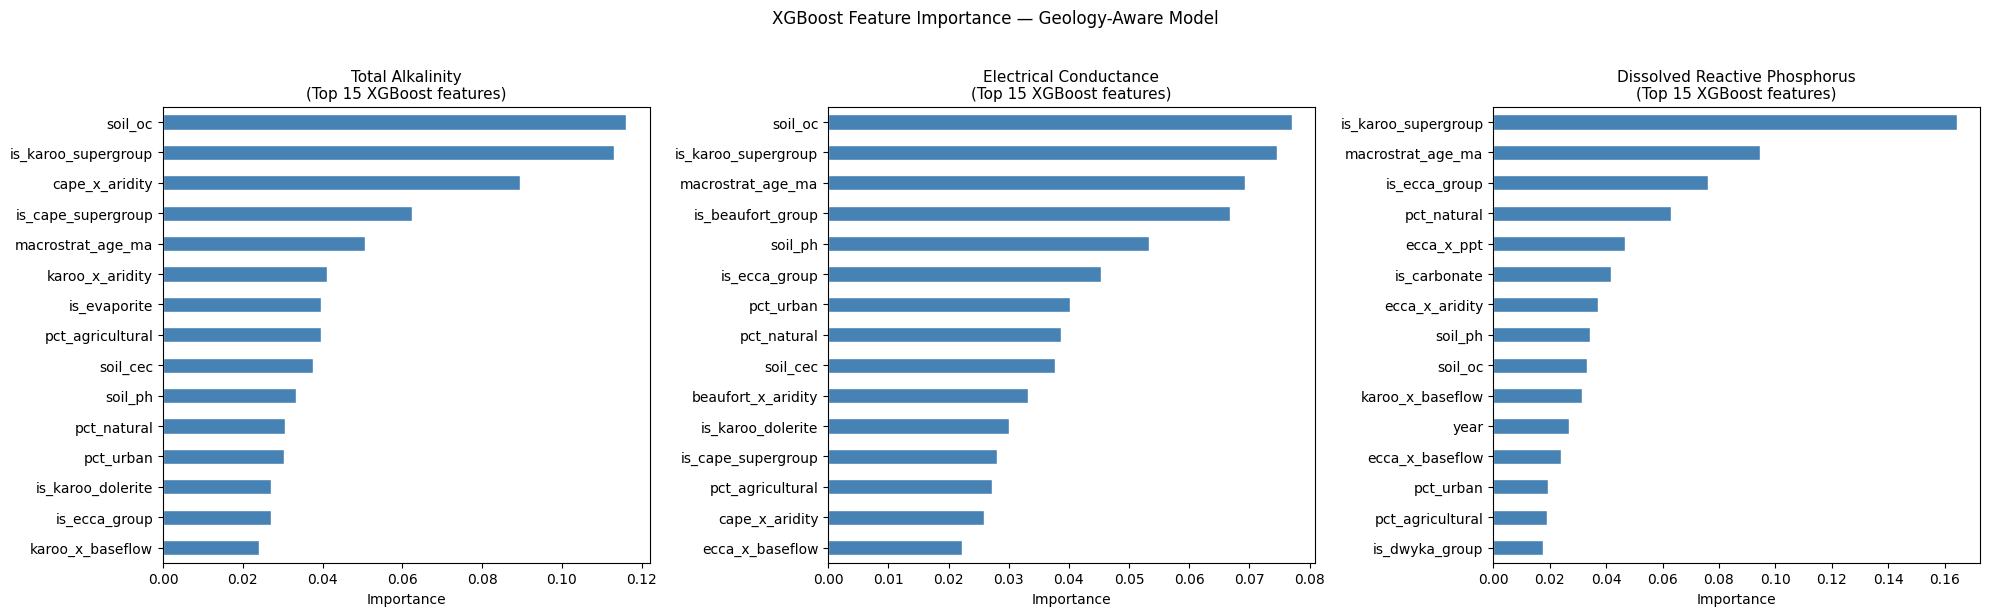

In [8]:
# ── Feature importance (XGBoost component) ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (t_key, t_col) in zip(axes, TARGET_COLS.items()):
    imp_ser = pd.Series(final_models[t_key]['xgb'].feature_importances_, index=FEATURE_COLS)
    top15   = imp_ser.nlargest(15)
    top15[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{t_col}\n(Top 15 XGBoost features)', fontsize=11)
    ax.set_xlabel('Importance')
plt.suptitle('XGBoost Feature Importance — Geology-Aware Model', y=1.02)
plt.tight_layout()
plt.savefig('../Miscellaneous/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

In [9]:
# ── Build validation feature matrix ───────────────────────────────────────────
val_feats   = val[FEATURE_COLS].copy()
val_imputed = imp_final.transform(val_feats)
val_s       = sc_final.transform(val_imputed)
val_r       = val_imputed

print(f"Validation feature shape : {val_imputed.shape}")
print(f"NaN after imputation     : {np.isnan(val_imputed).sum()}")
print()
print("Feature comparison — train vs val (◄ = >30% relative difference):")
for col in ['aridity', 'ppt', 'NDMI', 'soil_ph', 'soil_oc', 'baseflow_index',
            'is_karoo_supergroup', 'is_cape_supergroup',
            'is_beaufort_group', 'is_ecca_group', 'is_dwyka_group', 'is_karoo_dolerite',
            'macrostrat_age_ma']:
    tm, vm = train[col].mean(), val[col].mean()
    flag   = " ◄" if abs(vm - tm) / (abs(tm) + 1e-9) > 0.3 else ""
    print(f"  {col:25s}: train={tm:.3f}  val={vm:.3f}{flag}")
print()
print("Validation formation breakdown (rows):")
total = len(val)
for label, col in [('Beaufort Group','is_beaufort_group'), ('Karoo Dolerite','is_karoo_dolerite'),
                    ('Cape Supergroup','is_cape_supergroup'), ('Ecca Group','is_ecca_group'),
                    ('Dwyka Group','is_dwyka_group')]:
    n = int(val[col].sum())
    print(f"  {label:20s}: {n:3d} rows ({n/total:.0%})")

Validation feature shape : (200, 72)
NaN after imputation     : 0

Feature comparison — train vs val (◄ = >30% relative difference):
  aridity                  : train=13.808  val=6.483 ◄
  ppt                      : train=42.340  val=49.351
  NDMI                     : train=0.022  val=0.074 ◄
  soil_ph                  : train=6.546  val=6.503
  soil_oc                  : train=17.140  val=24.298 ◄
  baseflow_index           : train=12.081  val=7.549 ◄
  is_karoo_supergroup      : train=0.481  val=0.780 ◄
  is_cape_supergroup       : train=0.089  val=0.125 ◄
  is_beaufort_group        : train=0.159  val=0.610 ◄
  is_ecca_group            : train=0.191  val=0.010 ◄
  is_dwyka_group           : train=0.075  val=0.000 ◄
  is_karoo_dolerite        : train=0.039  val=0.160 ◄
  macrostrat_age_ma        : train=1096.018  val=257.309 ◄

Validation formation breakdown (rows):
  Beaufort Group      : 122 rows (61%)
  Karoo Dolerite      :  32 rows (16%)
  Cape Supergroup     :  25 rows (12%)
 

In [10]:
# ── Predict & save submission ─────────────────────────────────────────────────
predictions = {}
for t_key, t_col in TARGET_COLS.items():
    m = final_models[t_key]
    pred_log = m['w_ridge'] * m['ridge'].predict(val_s) + (1 - m['w_ridge']) * m['xgb'].predict(val_r)
    pred     = np.clip(np.expm1(pred_log), 0, None)
    predictions[t_key] = pred
    print(f"{t_col:35s}: min={pred.min():.1f}  mean={pred.mean():.1f}  median={np.median(pred):.1f}  max={pred.max():.1f}")

print()
print("Reference (20 training sites near Eastern Cape): TA≈87, EC≈296")

submission_df = pd.DataFrame({
    'Latitude':                      submission_tmpl['Latitude'].values,
    'Longitude':                     submission_tmpl['Longitude'].values,
    'Sample Date':                   submission_tmpl['Sample Date'].values,
    'Total Alkalinity':              predictions['TA'],
    'Electrical Conductance':        predictions['EC'],
    'Dissolved Reactive Phosphorus': predictions['DRP'],
})
submission_df.to_csv('../Data/submission.csv', index=False)
print("\n../Data/submission.csv saved.")
submission_df.head()

Total Alkalinity                   : min=21.5  mean=75.3  median=60.5  max=179.0
Electrical Conductance             : min=98.6  mean=274.1  median=250.0  max=544.7
Dissolved Reactive Phosphorus      : min=11.6  mean=18.7  median=19.0  max=31.6

Reference (20 training sites near Eastern Cape): TA≈87, EC≈296

../Data/submission.csv saved.


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-32.043333,27.822778,01-09-2014,83.555693,235.449282,19.008129
1,-33.329167,26.077500,16-09-2015,40.754646,493.153425,21.781705
2,-32.991639,27.640028,07-05-2015,49.739644,172.356713,19.639823
3,-34.096389,24.439167,07-02-2012,24.191776,176.285139,15.662316
4,-32.000556,28.581667,01-10-2014,60.222277,153.002186,15.621915


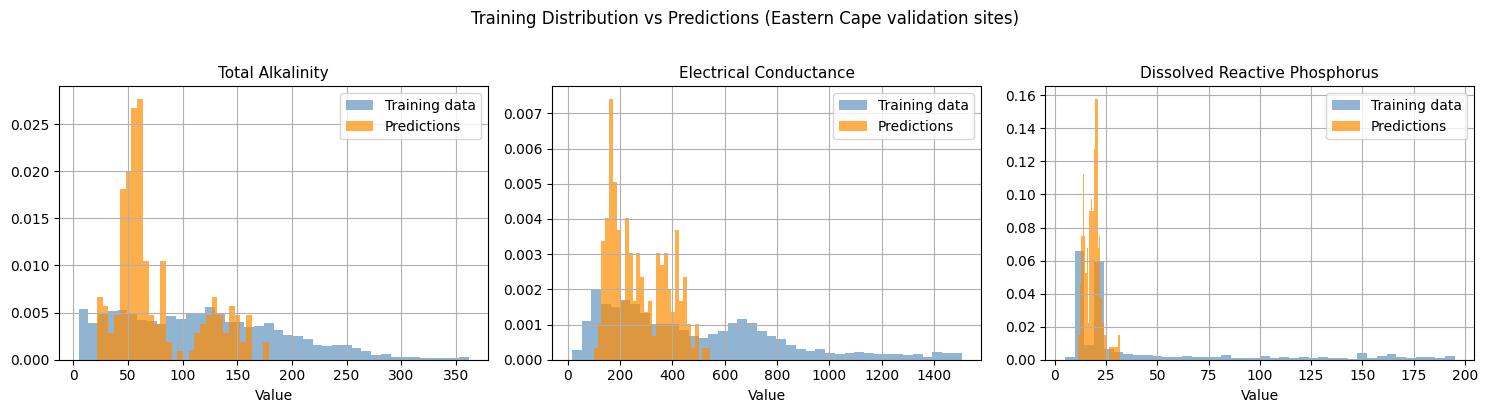

In [11]:
# ── Predicted vs training distribution check ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (t_key, t_col) in zip(axes, TARGET_COLS.items()):
    train[t_col].hist(bins=40, ax=ax, alpha=0.6, label='Training data', color='steelblue', density=True)
    pd.Series(predictions[t_key]).hist(bins=30, ax=ax, alpha=0.7, label='Predictions', color='darkorange', density=True)
    ax.set_title(t_col, fontsize=11)
    ax.legend(); ax.set_xlabel('Value')
plt.suptitle('Training Distribution vs Predictions (Eastern Cape validation sites)', y=1.02)
plt.tight_layout()
plt.savefig('../Miscellaneous/prediction_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## Model Summary

### Feature groups (72 total)
| Group | Key features | Primary target |
|---|---|---|
| TerraClimate | pet, ppt, tmax, soil, q, aet, def | TA, EC, DRP |
| Climate ratios | aridity, water_stress, baseflow_index, aet_pet | TA, EC |
| Temporal | month_sin/cos, is_wet_season, year | seasonal DRP |
| Landsat | NDMI, MNDWI, NDWI, NDVI, BSI, EVI, LSWI, thermal, … | DRP, temporal |
| Biological | bio_P_uptake, seasonal_drp_pulse, thermal_conc | DRP |
| Soil chemistry | soil_ph, soil_cec, soil_oc | TA, EC, DRP |
| Legacy geology | is_carbonate, is_evaporite, carbonate_dissolution | TA, EC |
| Land use | pct_agricultural, pct_urban, pct_natural | DRP, EC |
| Supergroup geology | is_karoo_supergroup, is_cape_supergroup, macrostrat_age_ma | TA, EC |
| Sub-Karoo geology | is_ecca_group, is_beaufort_group, is_dwyka_group, is_karoo_dolerite | TA, EC |
| Interactions | geology×climate, sub-Karoo×climate | all |

### Key geology insights
- **78% of validation rows = Beaufort Group** (Adelaide/Tarkastad subgroups): TA≈101, EC≈257
- **16% = Karoo Dolerite**: TA≈115, EC≈297
- **12.5% = Cape Supergroup** (Witteberg/Nardouw quartzite): TA≈54, EC≈423
- Ecca Group (1%) in validation — but well-represented in training (19%) providing a useful contrast

### Ensemble configuration
| Target | Ridge weight | XGB trees | Depth | LR | Ridge α |
|---|---|---|---|---|---|
| TA | 40% | 400 | 4 | 0.02 | 500 |
| EC | 40% | 400 | 4 | 0.02 | 500 |
| DRP | 50% | 300 | 3 | 0.03 | 1000 |

### External leaderboard
| Submission | External R² |
|---|---|
| Benchmark XGB (baseline) | −0.547 |
| Ridge + XGB with geography | −0.452 |
| + GLIM class dummies | −0.040 |
| **Current (sub-Karoo flags)** | *pending* |
| Best on leaderboard (Rishbha Jain) | 0.203 |

### Next steps (if score needs further improvement)
1. **Priority 2**: SRTM elevation + WorldClim 30yr mean aridity per site
2. **Priority 3**: Catchment-scale upstream geology fraction (HydroSHEDS + Macrostrat overlay)